In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

sns.set_style("whitegrid")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.9.0+cpu
CUDA available: False


In [7]:

import os

DATA_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection"

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images")

print("CSV exists:", os.path.exists(TRAIN_CSV))
print("Image folder exists:", os.path.exists(TRAIN_IMG_DIR))

CSV exists: True
Image folder exists: True


In [8]:
import pandas as pd

df = pd.read_csv(TRAIN_CSV)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3662, 2)


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


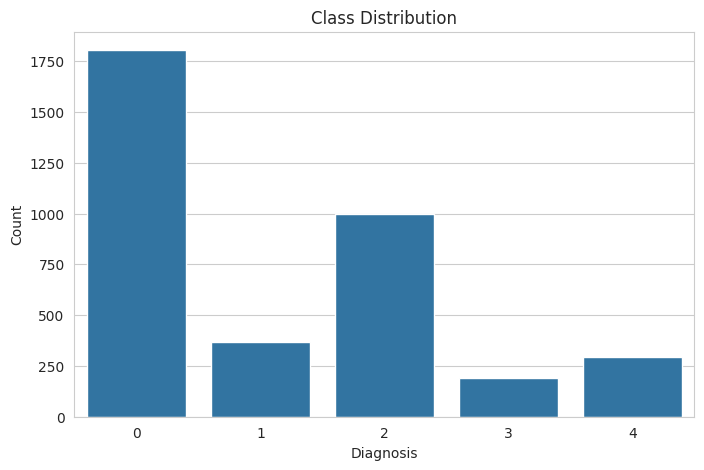

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

print(df["diagnosis"].value_counts())

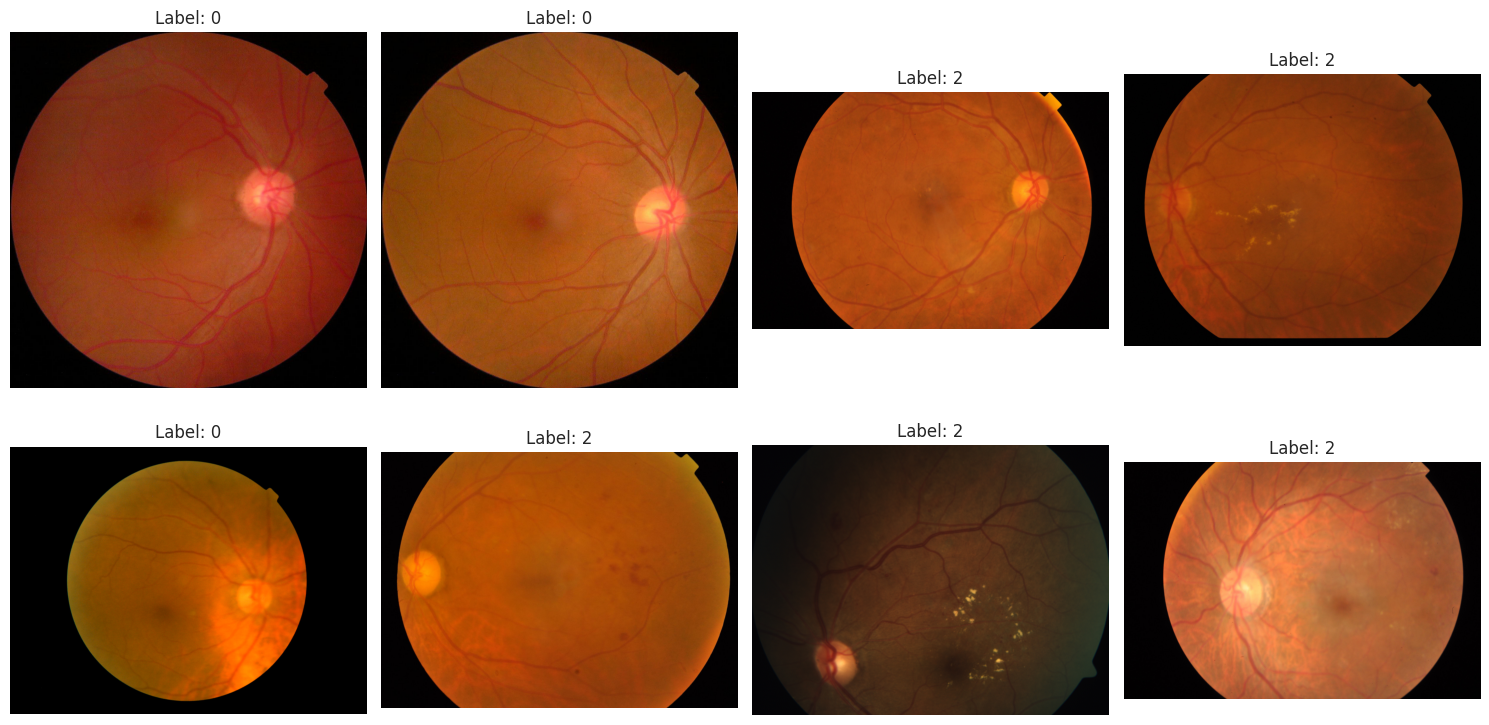

In [10]:
def show_random_images(df, img_dir, num_images=8):
    plt.figure(figsize=(15,8))
    
    sample_df = df.sample(num_images)
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img_path = os.path.join(img_dir, row["id_code"] + ".png")
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, num_images//2, i+1)
        plt.imshow(img)
        plt.title(f"Label: {row['diagnosis']}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_random_images(df, TRAIN_IMG_DIR)

100%|██████████| 200/200 [00:30<00:00,  6.53it/s]


Average Height: 1601.45
Average Width: 2148.13
Average Brightness: 63.0557413109727


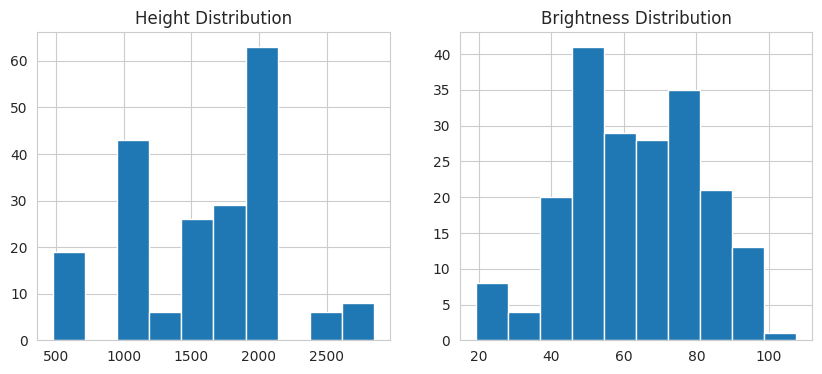

In [11]:
heights = []
widths = []
brightness_values = []

for idx in tqdm(range(200)): 
    img_id = df.loc[idx, "id_code"]
    img_path = os.path.join(TRAIN_IMG_DIR, img_id + ".png")
    
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    
    heights.append(h)
    widths.append(w)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness_values.append(np.mean(gray))

print("Average Height:", np.mean(heights))
print("Average Width:", np.mean(widths))
print("Average Brightness:", np.mean(brightness_values))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(heights, bins=10)
plt.title("Height Distribution")

plt.subplot(1,2,2)
plt.hist(brightness_values, bins=10)
plt.title("Brightness Distribution")

plt.show()

In [19]:
def crop_image_from_gray(img, tol=7):
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    elif img.ndim == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        mask = gray > tol
        
        if mask.any():
            img = img[np.ix_(mask.any(1), mask.any(0))]
        return img


def ben_graham_preprocessing(img):
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (512, 512))
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 30), -4, 128)
    return img


def clahe_preprocessing(img):
    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(img_lab)
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    
    img_lab = cv2.merge((l,a,b))
    img = cv2.cvtColor(img_lab, cv2.COLOR_LAB2BGR)
    return img

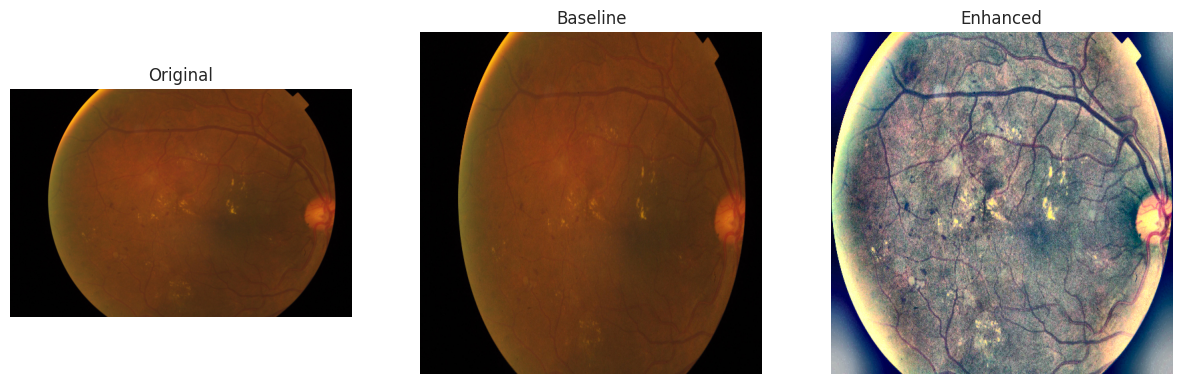

In [20]:
sample_id = df.iloc[0]["id_code"]
img_path = os.path.join(TRAIN_IMG_DIR, sample_id + ".png")

original = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

baseline = cv2.resize(original_rgb, (512,512))

enhanced = ben_graham_preprocessing(original)
enhanced = clahe_preprocessing(enhanced)
enhanced = cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(original_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(baseline)
plt.title("Baseline")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(enhanced)
plt.title("Enhanced")
plt.axis("off")

plt.show()

In [21]:
class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, enhanced=False):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.enhanced = enhanced
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["id_code"] + ".png")
        
        image = cv2.imread(img_path)
        
        if self.enhanced:
            image = ben_graham_preprocessing(image)
            image = clahe_preprocessing(image)
        
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        label = torch.tensor(row["diagnosis"], dtype=torch.long)
        
        return image, label

In [22]:

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["diagnosis"],
    random_state=42
)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 2929
Val size: 733


In [23]:
baseline_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [24]:
train_dataset = APTOSDataset(
    train_df,
    TRAIN_IMG_DIR,
    transform=baseline_transform,
    enhanced=False
)

val_dataset = APTOSDataset(
    val_df,
    TRAIN_IMG_DIR,
    transform=baseline_transform,
    enhanced=False
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 367
Val batches: 92


In [25]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(df["diagnosis"]),
    y=df["diagnosis"]
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([0.4058, 1.9795, 0.7331, 3.7948, 2.4827])
